# Neuronal Models and Application of UDEs to it

## Intro
[1] In neurosciences, there are two main ways (three, actually, but we will consider only these two blablabla) to model a neuron:
1. *Rate models*, we let $r$ describe a unit's activity and it follows a differential equation
2. *Spike models*, we describe each neuron considering more dimensions for each unit, such as the membrane dynamics, the geometry of the neuron (compartments), et cetera...

We will mainly focus on the first case in these notebooks.

A first example of the first case is as follows:
$$
\tau \dot r = -r + \varphi(I_{\text{ext} }+Jr)
$$
Where $\varphi$ is some sort of transfer function of neurons, and it can take many forms (for example, threshold-linear, sigmoidal, et cetera...); $J$ describes the strengh of the intra-population connections: if $<0$, the neuron is said to be inhibitory, otherwise it is said to be excitatory.

We can extend this into a network of neurons in two ways:

The first one is to introduce a continuous variable $x$ which denotes some sort of location for the neuron. In this case we have the partial integro-differential equation (this is also known as the continuum approximation):

$$
\tau \partial_t [r(x)] = -r(x) + \varphi \left(I_{\text{ext} }(x,t) + \int_\Omega J(x,y)r(y)\text{ d}y \right) 
$$

One particular choice of $x$ is to model it as some sort of angle $\theta \in [-\pi, \pi]$, obtaining the so-called ring-model:


$$
\tau \partial_t [r(\theta, t)] = -r(\theta) + \varphi \left(I_{\text{ext} }(\theta,t) + \int_\pi^\pi J(\theta,\theta')r(\theta', t)\text{ d}\theta' \right) 
$$

Otherwise it can be formulated in a "discrete" fashion, as in [2]:

$$
\tau \dot r_k = -r_k + \varphi\left(\sum_n w_{nk} r_n + h_k\right)
$$

(TO DO: approfondire bene il discorso leggendo l'intero capitolo, potenziale collegamento con lotka-volterra per fare una transizione fluida nella tesi)

[1] the review paper
[2] the neural field theory book

We will first model the basic neuron model and simulate it, then attempt to use UDEs to infer the transfer function (and possibly the parameter J as well), then we will move onto discrete neuron networks.

## Part 1: Firing Rate Model
In the first part, we will focus on the *fire rate model* of a single neuron. That is, the model of the following type:
$$
\tau \dot r = -r + \varphi(I_{\text{ext} }+Jr)
$$

To simplify, we will assume for the adimensionalized case $\tau = 1$.

In the following examples, we will define $\varphi$ as the threshold function, that is
$$
\varphi_T(I) := \max\{0, I-T\}
$$
And $I_{\text{ext}}$ can be modelled either as a constant or a time-valued function.

We will apply UDEs in three cases:
1. Learning the external impulse function $I(t)$, with the choice of $I(t)$ being the gaussian peak centered at $\hat t$ with variance $\sigma$, defined as
$$
I(t, \hat t, \sigma):=2e^{-\frac{(t-\hat t)^2}{2\sigma^2}}
$$
The UDE to be trained is defined as follows:
$$
\dot r = -r + \varphi(\texttt{NN}(t) + Jr)
$$

2. Learning the activation function, with it being the threshold function and having a constant impulse function. The UDE in this case is
$$
\dot r = -r + \texttt{NN}(I_\text{ext} + Jr)
$$

3. Both of the two cases above combined, so our UDE model will look like as follows:
$$
\dot r = -r + \texttt{NN}_1(\texttt{NN}_2(t) + Jr)
$$

In [2]:
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch 
from torch import nn, optim
from torchdiffeq import odeint

In [30]:
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    r_max = 3
    activation = r_max / (1+np.exp(-1*(I_ext + J*x - T)))
    return [-x + activation]

In [31]:
T_max = 10

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (0.1,), args=(1.0, 2, 1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-8, atol=1e-8)


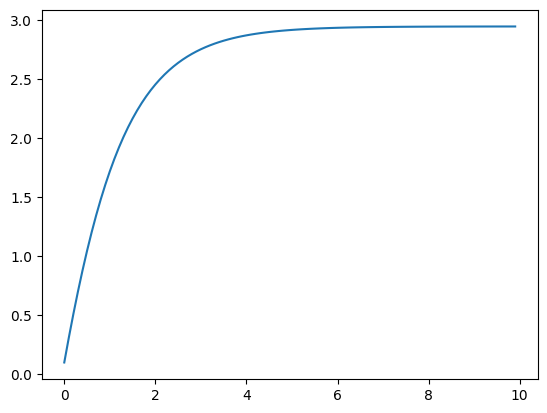

In [32]:
plt.plot(np.arange(0, T_max, 0.1), sol.y[0])

plt.show()

### Experiment 1: Only Impulse

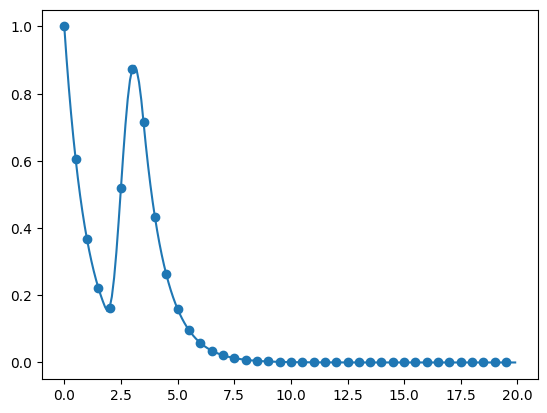

In [107]:
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    activation = np.maximum(0, I_ext(t)+J*x-T)
    return [-x + activation]

def I(t, t_peak, sigma):
    return 2.0 * np.exp(-((t - t_peak)**2) / (2 * sigma**2)) 
    
T_max = 20

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (1.,), args=(1, lambda t: I(t, 2.5, 0.5), 1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-8, atol=1e-8)

plt.plot(sol.t, sol.y[0])

X_train = sol.y[0][::5]
T_train = sol.t[::5]

plt.scatter(T_train, X_train)

plt.show()

In [118]:
# hmmm... i can try to make an UDE which learns the impulse!!!!
class my_universal_neuron(nn.Module):
    def __init__(self, transfer, threshold, strength):
        super().__init__()

        self.transfer = transfer # N.B. TRANSFER HAS TO WORK ON TENSORS!!!!!!!!
        self.register_buffer("threshold", torch.as_tensor(threshold, dtype=torch.float32))
        self.register_buffer("strength", torch.as_tensor(strength, dtype=torch.float32))

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )


    def forward(self, t, x):
        external_impulse = self.net(t.reshape(1,1))

        return -x + self.transfer(external_impulse + self.strength * x, self.threshold)
    
def transfer_threshold(I, T):
    return torch.maximum(
        torch.tensor([0.], requires_grad=True),
        I-T
    )

def fake_threshold(I, T):
    return torch.nn.functional.softplus(1000 * (I - T)) / 1000

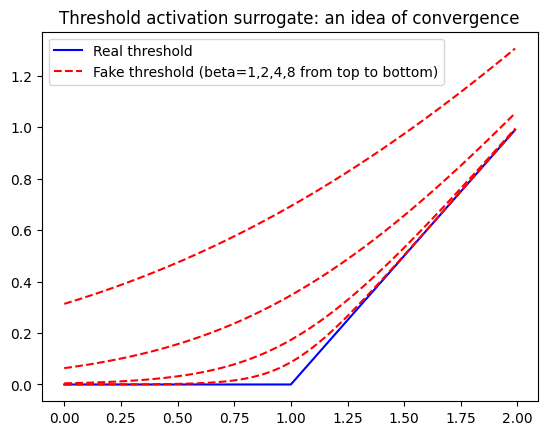

In [182]:
# Problem: the actual transfer threshold's derivative behaves badly, as it vanishes for values under the threshold. (and as a matter of fact is not differentiable in some points) 
# So we replaced by its "soft" surrogate, known also as the "softmax" function (in this case we use the softplus function)
# To give an idea we will plot the two transfer functions:

x_transfer = np.arange(0, 2, 0.01)
y_threshold = np.maximum(0, x_transfer-1)
y_fake_threshold1 = np.log(1+ np.exp( (x_transfer-1)))
y_fake_threshold2 = np.log(1+ np.exp( 2* (x_transfer-1))) / 2
y_fake_threshold3 = np.log(1+ np.exp( 4*(x_transfer-1))) / 4
y_fake_threshold4 = np.log(1+ np.exp( 8*(x_transfer-1))) / 8

fig, ax = plt.subplots()

ax.plot(x_transfer, y_threshold, 'b', label="Real threshold")
ax.plot(x_transfer, y_fake_threshold1, 'r--', label="Fake threshold (beta=1,2,4,8 from top to bottom)")
ax.plot(x_transfer, y_fake_threshold2, 'r--')
ax.plot(x_transfer, y_fake_threshold3, 'r--')
ax.plot(x_transfer, y_fake_threshold4, 'r--')

plt.legend()
plt.title("Threshold activation surrogate: an idea of convergence")

plt.show()

In [124]:
from tqdm import tqdm 

my_monkey = my_universal_neuron(
    fake_threshold, torch.tensor([1.]), torch.tensor([1.])
)

lr = 0.003
optimizer = optim.Adam(my_monkey.parameters(), lr=lr)

n_epochs = 1000
rtol = 1e-7

t_train_torch = torch.tensor(T_train)

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    my_monkey.zero_grad()
    
    # forward solution
    x_pred = odeint(my_monkey, 
                    torch.tensor([1.], requires_grad=False),
                    t_train_torch,
                    rtol=rtol
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0., requires_grad=True)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {EPOCH}: MSE Loss = {loss.item():.4e}")


Epoch 0: MSE Loss = 4.0231e-02
Epoch 1: MSE Loss = 4.0184e-02
Epoch 2: MSE Loss = 4.0103e-02
Epoch 3: MSE Loss = 3.9977e-02
Epoch 4: MSE Loss = 3.9804e-02
Epoch 5: MSE Loss = 3.9584e-02
Epoch 6: MSE Loss = 3.9423e-02
Epoch 7: MSE Loss = 3.9402e-02
Epoch 8: MSE Loss = 3.7231e-02
Epoch 9: MSE Loss = 2.8654e-02
Epoch 10: MSE Loss = 5.9409e-02
Epoch 11: MSE Loss = 2.6810e-02
Epoch 12: MSE Loss = 3.1324e-02
Epoch 13: MSE Loss = 3.6190e-02
Epoch 14: MSE Loss = 3.8083e-02
Epoch 15: MSE Loss = 3.8728e-02
Epoch 16: MSE Loss = 3.8980e-02
Epoch 17: MSE Loss = 3.9102e-02
Epoch 18: MSE Loss = 3.9156e-02
Epoch 19: MSE Loss = 3.9195e-02
Epoch 20: MSE Loss = 3.9234e-02
Epoch 21: MSE Loss = 3.9270e-02
Epoch 22: MSE Loss = 3.9300e-02
Epoch 23: MSE Loss = 3.9325e-02
Epoch 24: MSE Loss = 3.9347e-02
Epoch 25: MSE Loss = 3.9366e-02
Epoch 26: MSE Loss = 3.9382e-02
Epoch 27: MSE Loss = 3.9396e-02
Epoch 28: MSE Loss = 3.9408e-02
Epoch 29: MSE Loss = 3.9421e-02
Epoch 30: MSE Loss = 3.9432e-02
Epoch 31: MSE Loss

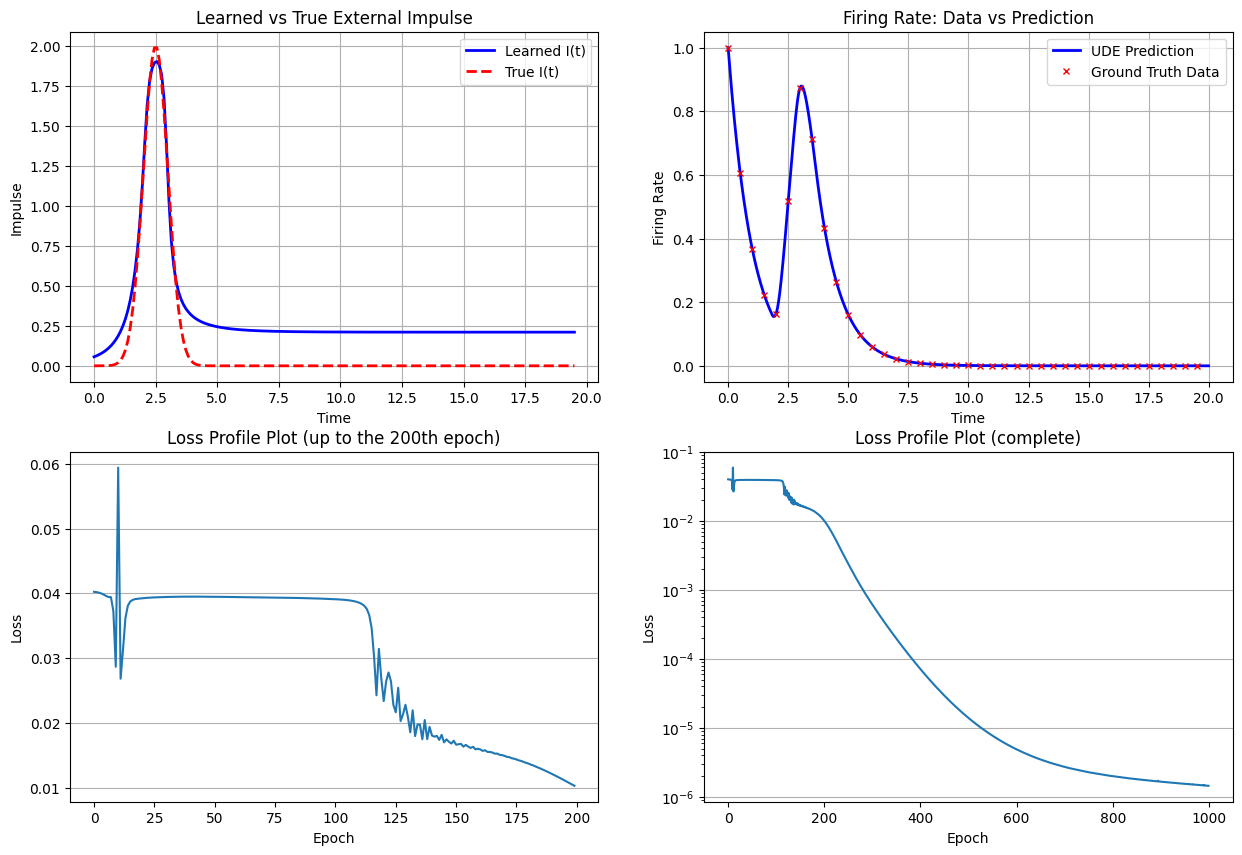

In [164]:
# Plot the learned impulse function
t_plot = torch.linspace(0, T_train[-1], 200)
with torch.no_grad():
    I_learned = torch.stack([my_monkey.net(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()

plt.figure(figsize=(15, 10))

# Plot 1: Learned impulse vs true impulse
plt.subplot(2, 2, 1)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned I(t)')
t_true = np.linspace(0, T_train[-1], 200)
I_true = np.array([I(t, 2.5, 0.5) for t in t_true])
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True I(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True External Impulse')
plt.grid()

# Plot 2: Predictions vs data
plt.subplot(2, 2, 2)
x_pred = odeint(my_monkey, 
                torch.tensor([X_train[0]], dtype=torch.float32).unsqueeze(1),
                T_eval := torch.arange(0,20, 0.01))
plt.plot(T_eval.detach().numpy(), x_pred.detach().numpy().squeeze(), 'b-', linewidth=2, label='UDE Prediction')
plt.plot(T_train, X_train, 'xr', markersize=4, label='Ground Truth Data')

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.legend()
plt.title('Firing Rate: Data vs Prediction')
plt.grid()

# Plot 3: losses with semilogy
# NOTE: To obtain this data, I copied the output of the cell that printed the losses and processed it with regex to obtain a readable .csv file by the standards
losses_data = np.loadtxt("./tanh_impulse_losses_processed.txt", delimiter="\t")

plt.subplot(2, 2, 3)
plt.plot(losses_data[:200, 0], losses_data[:200, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Profile Plot (up to the 200th epoch)")

plt.grid(axis='y')

plt.subplot(2, 2, 4)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Profile Plot (complete)")

plt.grid(axis='y')

plt.show()



problemi di identificabilità dovuta alla threshold più bassa dell'impulso (oss.)

**TODO: metto threshold = 0.1, 0.05** 

As we can see, this worked! However, an approximation of the activation function was necessary as its gradient tend to vanish under the threshold

In [128]:
torch.save(my_monkey.state_dict(), "./trained_impulse_nn_relu.dinomeng")

### Experiment 2: Only Activation

Instead of using an ad-hoc surrogate activation function, we can model such function with a neural network. Let's try doing this one with a constant external impulse:

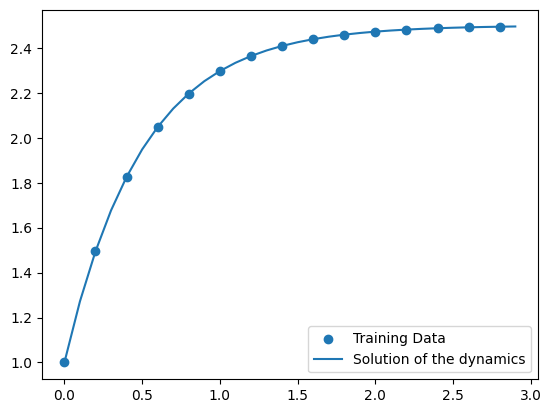

In [267]:
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    activation = np.maximum(0, I_ext+J*x-T)
    return [-x + activation]

T_max = 3

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (1.,), args=(1, 6, -1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-10, atol=1e-10)

X_train = sol.y[0][::2]
T_train = sol.t[::2]

plt.scatter(T_train, X_train, label="Training Data")

plt.plot(np.arange(0, T_max, 0.1), sol.y[0], label="Solution of the dynamics")

plt.legend()

plt.show()

In [114]:
class learn_activation(nn.Module):
    def __init__(self, Iext, J):
        super().__init__()

        self.I_ext = Iext 
        self.J = J

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, t, x):
        return -x + self.net(self.I_ext + self.J * x )

In [115]:
monkey_reaction = learn_activation(
     torch.tensor([6.]), torch.tensor([-1.])
)

lr = 0.003
optimizer = optim.Adam(monkey_reaction.parameters(), lr=lr)

n_epochs = 2000
rtol = 1e-7

t_train_torch = torch.tensor(T_train)

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    monkey_reaction.zero_grad()
    
    # forward solution
    x_pred = odeint(monkey_reaction, 
                    torch.tensor([1.], requires_grad=False),
                    t_train_torch,
                    rtol=rtol
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0., requires_grad=True)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    print(f"{EPOCH}\t{loss.item():.4e}")


0	4.5863e+00
1	4.5066e+00
2	4.4379e+00
3	4.3695e+00
4	4.2997e+00
5	4.2289e+00
6	4.1584e+00
7	4.0889e+00
8	4.0345e+00
9	3.9815e+00
10	3.9253e+00
11	3.8622e+00
12	3.7964e+00
13	3.7277e+00
14	3.6542e+00
15	3.5757e+00
16	3.4919e+00
17	3.4026e+00
18	3.3078e+00
19	3.2071e+00
20	3.1006e+00
21	2.9882e+00
22	2.8699e+00
23	2.7457e+00
24	2.6157e+00
25	2.4803e+00
26	2.3397e+00
27	2.1944e+00
28	2.0450e+00
29	1.8924e+00
30	1.7373e+00
31	1.5810e+00
32	1.4246e+00
33	1.2696e+00
34	1.1174e+00
35	9.6953e-01
36	8.2770e-01
37	6.9351e-01
38	5.6853e-01
39	4.5419e-01
40	3.5170e-01
41	2.6207e-01
42	1.8595e-01
43	1.2193e-01
44	7.1923e-02
45	3.6117e-02
46	1.3901e-02
47	4.0087e-03
48	4.5646e-03
49	1.3098e-02
50	2.6635e-02
51	4.2231e-02
52	5.7475e-02
53	7.0622e-02
54	8.0569e-02
55	8.6775e-02
56	8.9156e-02
57	8.7977e-02
58	8.3747e-02
59	7.7118e-02
60	6.8800e-02
61	5.9491e-02
62	5.0459e-02
63	4.2369e-02
64	3.4506e-02
65	2.7207e-02
66	2.0724e-02
67	1.5218e-02
68	1.0772e-02
69	7.3901e-03
70	5.0201e-03
71	3.5603e-03
72

In [130]:
torch.save(monkey_reaction.state_dict(), "./trained_activation_nn.dinomeng")

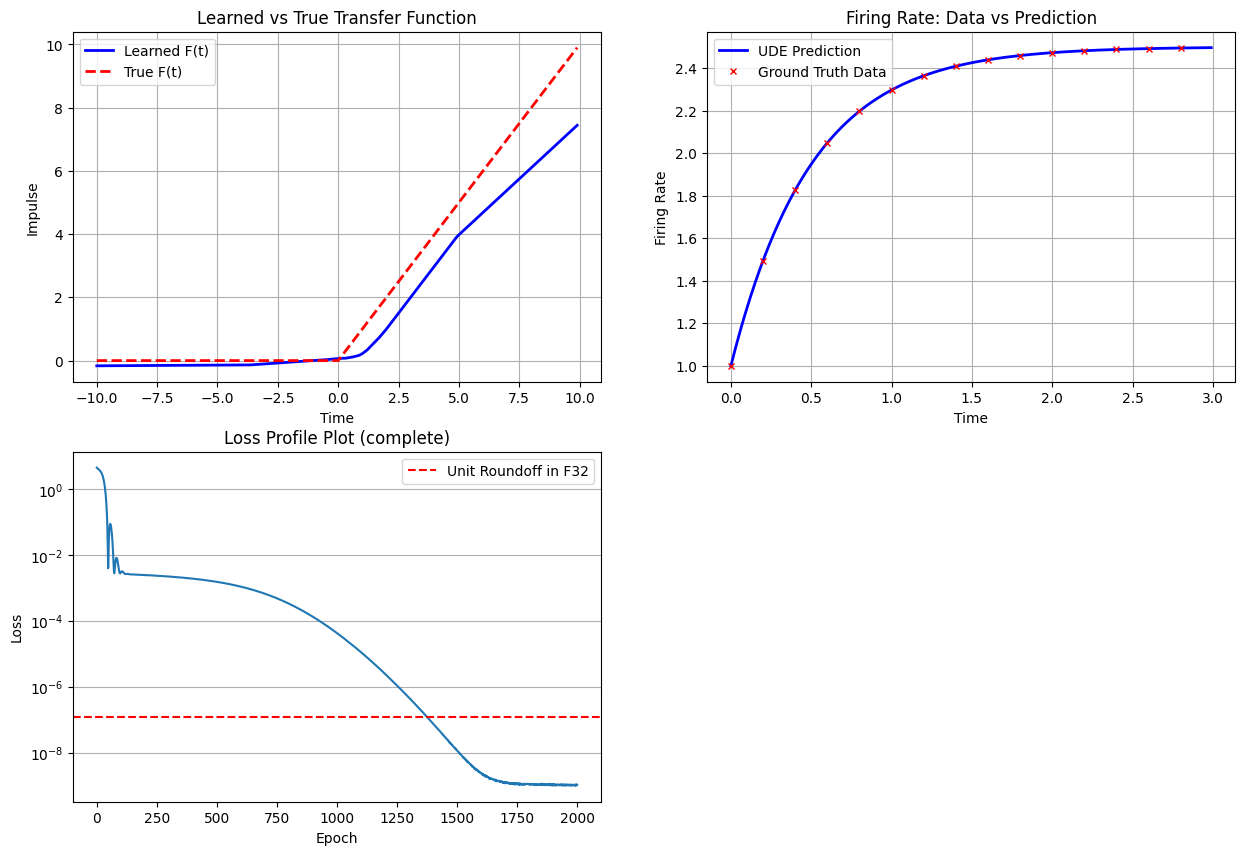

In [268]:
# Plot the transfer function
i_plot = torch.arange(-10, 10, 0.1)
with torch.no_grad():
    act_learned = torch.stack([monkey_reaction.net(torch.tensor([[I]], dtype=torch.float32)) 
                             for I in i_plot]).squeeze()

plt.figure(figsize=(15, 10))

# Plot 1: Learned Activation vs true activation
plt.subplot(2, 2, 1)
plt.plot(i_plot.numpy(), act_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')

i_true = np.arange(-10, 10, 0.1)

act_true = np.maximum(0, i_true)

plt.plot(i_true, act_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True Transfer Function')
plt.grid()

# Plot 2: Predictions vs data
plt.subplot(2, 2, 2)
x_pred = odeint(monkey_reaction, 
                torch.tensor([X_train[0]], dtype=torch.float32).unsqueeze(1),
                T_eval := torch.arange(0,3, 0.01))

plt.plot(T_eval.detach().numpy(), x_pred.detach().numpy().squeeze(), 'b-', linewidth=2, label='UDE Prediction')
plt.plot(T_train, X_train, 'xr', markersize=4, label='Ground Truth Data')

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.legend()
plt.title('Firing Rate: Data vs Prediction')
plt.grid()

# Plot 3: losses with semilogy
losses_data = np.loadtxt("./trained_activation_losses.txt", delimiter="\t")

plt.subplot(2, 2, 3)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.axhline(2**(-23), linestyle="--", color='r', label="Unit Roundoff in F32")
plt.legend()

plt.title("Loss Profile Plot (complete)")
plt.grid(axis='y')

plt.show()



todo: provare con altri iperparametri della rete

vedo tool per fine tuning applicato a questo caso (diff. eqs)

### Experiment 3: Both

In [134]:
# Now let's try doing both at the same time: learn both the impulse function and the transfer function at the same time

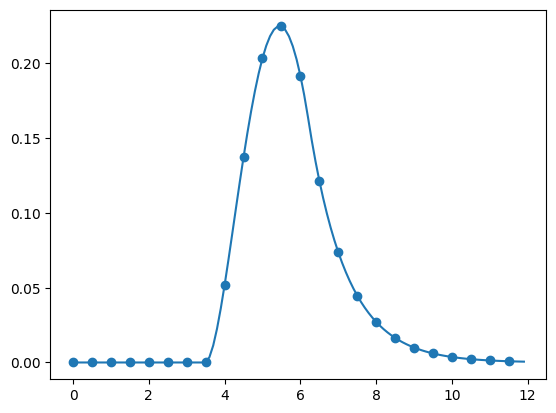

In [ ]:
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    activation = np.maximum(0, I_ext(t)+J*x-T)
    return [-x + activation]

def I(t, t_peak, sigma):
    return 2.0 * np.exp(-((t - t_peak)**2) / (2 * sigma**2)) 
    
T_max = 12

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (0.,), args=(1.5, lambda t: I(t, 5, 2), -1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-8, atol=1e-8)

plt.plot(sol.t, sol.y[0])

X_train = sol.y[0][::5]
T_train = sol.t[::5]

plt.scatter(T_train, X_train)

plt.show()

In [244]:
class learn_all(nn.Module):
    def __init__(self, J):
        super().__init__()

        self.J = J

        self.net_transfer = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

        self.net_impulse = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )


    def forward(self, t, x):
        return -x + self.net_transfer(self.net_impulse(t.reshape(1, 1)) + self.J * x )

In [249]:
advanced_monkey = learn_all(
    torch.tensor([-1.]),
)

lr = 0.0005


optimizer = optim.Adam(advanced_monkey.parameters(), lr=lr)


n_epochs = 1000
rtol = 1e-7

t_train_torch = torch.tensor(T_train)

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    advanced_monkey.zero_grad()
    
    # forward solution
    x_pred = odeint(advanced_monkey, 
                    torch.tensor([0.], requires_grad=False),
                    t_train_torch,
                    rtol=rtol
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0., requires_grad=True)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()

    print(f"{EPOCH}\t{loss.item():.7e}")


0	7.3644049e-02
1	7.1811229e-02
2	7.0141852e-02
3	6.9039211e-02
4	6.8122119e-02
5	6.7059614e-02
6	6.5917864e-02
7	6.4766936e-02
8	6.3684531e-02
9	6.2703900e-02
10	6.1739344e-02
11	6.0807321e-02
12	5.9901219e-02
13	5.9019078e-02
14	5.8155667e-02
15	5.7303980e-02
16	5.6457948e-02
17	5.5618256e-02
18	5.4785475e-02
19	5.3960148e-02
20	5.3142618e-02
21	5.2333232e-02
22	5.1532190e-02
23	5.0739672e-02
24	4.9958590e-02
25	4.9193788e-02
26	4.8444528e-02
27	4.7709402e-02
28	4.6984818e-02
29	4.6267424e-02
30	4.5554712e-02
31	4.4899091e-02
32	4.4259395e-02
33	4.3626372e-02
34	4.3000668e-02
35	4.2381857e-02
36	4.1768696e-02
37	4.1159485e-02
38	4.0553212e-02
39	3.9949212e-02
40	3.9347790e-02
41	3.8750149e-02
42	3.8162414e-02
43	3.7634626e-02
44	3.7121709e-02
45	3.6612425e-02
46	3.6106564e-02
47	3.5603974e-02
48	3.5104435e-02
49	3.4607738e-02
50	3.4113657e-02
51	3.3621911e-02
52	3.3132236e-02
53	3.2644346e-02
54	3.2157909e-02
55	3.1672519e-02
56	3.1154955e-02
57	3.0620873e-02
58	3.0075634e-02
59	2.95

In [250]:
# just 500 more epochs bro
for EPOCH in (range(1000, 1500)):
    optimizer.zero_grad()
    advanced_monkey.zero_grad()
    
    # forward solution
    x_pred = odeint(advanced_monkey, 
                    torch.tensor([0.], requires_grad=False),
                    t_train_torch,
                    rtol=rtol
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0., requires_grad=True)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()

    print(f"{EPOCH}\t{loss.item():.7e}")

1000	1.8516383e-05
1001	1.8494076e-05
1002	1.8470048e-05
1003	1.8449120e-05
1004	1.8427256e-05
1005	1.8402719e-05
1006	1.8376964e-05
1007	1.8355096e-05
1008	1.8332874e-05
1009	1.8311159e-05
1010	1.8287597e-05
1011	1.8265402e-05
1012	1.8243654e-05
1013	1.8221595e-05
1014	1.8198583e-05
1015	1.8173883e-05
1016	1.8153345e-05
1017	1.8129207e-05
1018	1.8109309e-05
1019	1.8085360e-05
1020	1.8061504e-05
1021	1.8041612e-05
1022	1.8018907e-05
1023	1.7997378e-05
1024	1.7972172e-05
1025	1.7951725e-05
1026	1.7929529e-05
1027	1.7908011e-05
1028	1.7884817e-05
1029	1.7865508e-05
1030	1.7841236e-05
1031	1.7821736e-05
1032	1.7795244e-05
1033	1.7774581e-05
1034	1.7755438e-05
1035	1.7732435e-05
1036	1.7711413e-05
1037	1.7690088e-05
1038	1.7668810e-05
1039	1.7646276e-05
1040	1.7624538e-05
1041	1.7601802e-05
1042	1.7580658e-05
1043	1.7558594e-05
1044	1.7538152e-05
1045	1.7517998e-05
1046	1.7495819e-05
1047	1.7473445e-05
1048	1.7453931e-05
1049	1.7432014e-05
1050	1.7409404e-05
1051	1.7388596e-05
1052	1.73678

In [254]:
# JUST ANOTHER 500 epochs bro trust me (also increase learning rate by a ltitle bit)
lr = 0.001
optimizer = optim.Adam(advanced_monkey.parameters(), lr=lr)


n_epochs = 1000
rtol = 1e-7

t_train_torch = torch.tensor(T_train)

for EPOCH in range(1500, 2000):
    optimizer.zero_grad()
    advanced_monkey.zero_grad()
    
    # forward solution
    x_pred = odeint(advanced_monkey, 
                    torch.tensor([0.], requires_grad=False),
                    t_train_torch,
                    rtol=rtol
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0., requires_grad=True)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()

    print(f"{EPOCH}\t{loss.item():.7e}")


1500	3.4731292e-04
1501	1.3938674e-04
1502	2.4861327e-04
1503	5.2689629e-05
1504	3.5236022e-05
1505	1.3305320e-04
1506	1.3102520e-04
1507	4.9337163e-05
1508	9.5770529e-06
1509	4.7488236e-05
1510	8.4114406e-05
1511	6.0916122e-05
1512	1.8882691e-05
1513	1.3319125e-05
1514	3.9001756e-05
1515	5.2941876e-05
1516	3.7015885e-05
1517	1.3549929e-05
1518	1.0536666e-05
1519	2.6506716e-05
1520	3.5419198e-05
1521	2.4945643e-05
1522	1.0716387e-05
1523	1.0197244e-05
1524	1.9898025e-05
1525	2.4154562e-05
1526	1.7414481e-05
1527	9.4240668e-06
1528	1.0128607e-05
1529	1.6318614e-05
1530	1.7597828e-05
1531	1.2198084e-05
1532	8.1427615e-06
1533	1.0236214e-05
1534	1.3968340e-05
1535	1.3422185e-05
1536	9.6675676e-06
1537	8.1261824e-06
1538	1.0219593e-05
1539	1.1836152e-05
1540	1.0290783e-05
1541	8.1913859e-06
1542	8.5692709e-06
1543	1.0176514e-05
1544	1.0098503e-05
1545	8.4957410e-06
1546	7.8785424e-06
1547	8.8597053e-06
1548	9.4529223e-06
1549	8.6287855e-06
1550	7.8204966e-06
1551	8.1894814e-06
1552	8.77745

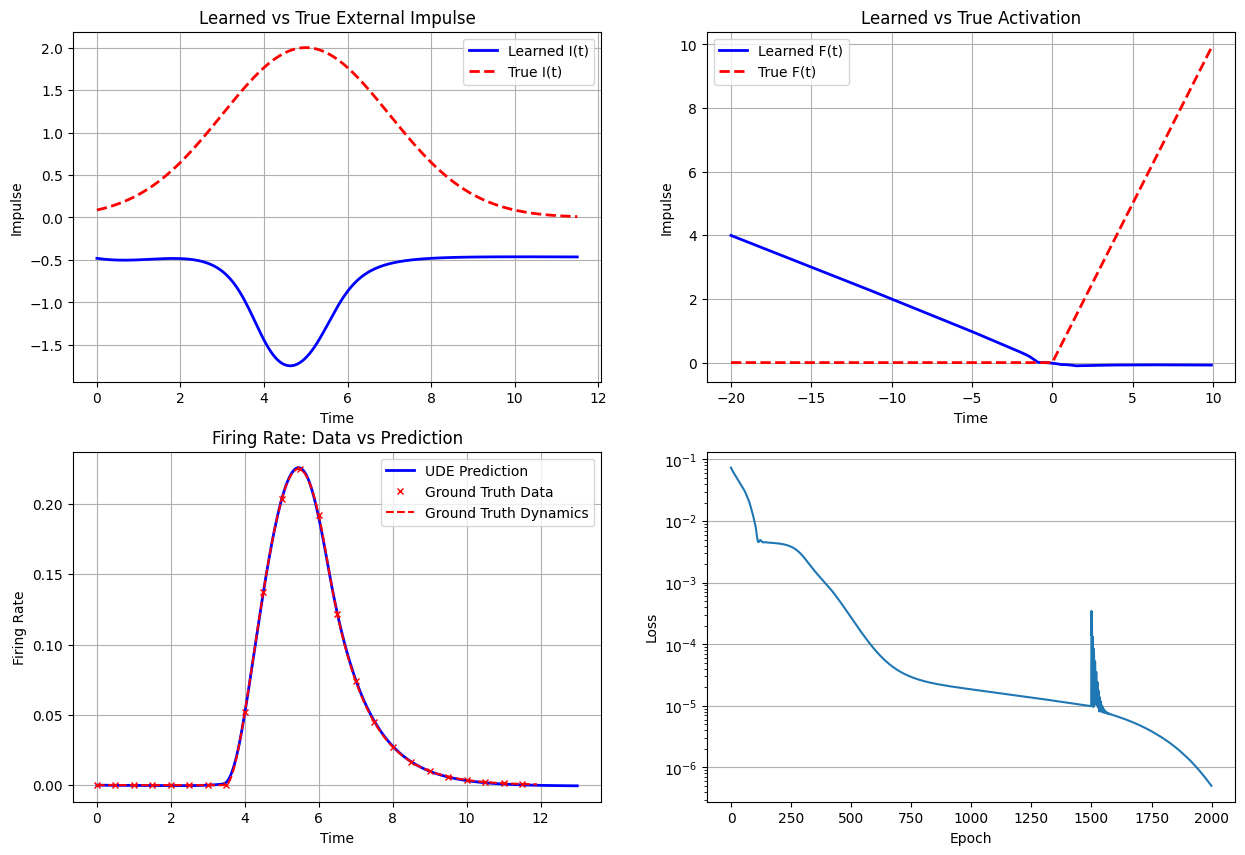

In [263]:
# Plot the learned impulse function
t_plot = torch.linspace(0, T_train[-1], 200)
with torch.no_grad():
    I_learned = torch.stack([advanced_monkey.net_impulse(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()

plt.figure(figsize=(15, 10))

# Plot 1: Learned impulse vs true impulse
plt.subplot(2, 2, 1)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned I(t)')
t_true = np.linspace(0, T_train[-1], 200)
I_true = np.array([I(t, 5, 2) for t in t_true])
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True I(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True External Impulse')
plt.grid()

# Plot the transfer function
i_plot = torch.arange(-20, 10, 0.1)
with torch.no_grad():
    act_learned = torch.stack([advanced_monkey.net_transfer(torch.tensor([[I]], dtype=torch.float32)) 
                             for I in i_plot]).squeeze()

# Plot 2: Learned Activation vs true activation
plt.subplot(2, 2, 2)
plt.plot(i_plot.numpy(), act_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')

i_true = np.arange(-20, 10, 0.1)

act_true = np.maximum(0, i_true)

plt.plot(i_true, act_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True Activation')
plt.grid()


# Plot 3: Predictions vs data
plt.subplot(2, 2, 3)
x_pred = odeint(advanced_monkey, 
                torch.tensor([X_train[0]], dtype=torch.float32).unsqueeze(1),
                T_eval := torch.arange(0,13, 0.01))
plt.plot(T_eval.detach().numpy(), x_pred.detach().numpy().squeeze(), 'b-', linewidth=2, label='UDE Prediction')
plt.plot(T_train, X_train, 'xr', markersize=4, label='Ground Truth Data')
plt.plot(sol.t, sol.y[0], 'r--', markersize=4, label='Ground Truth Dynamics')

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.legend()
plt.title('Firing Rate: Data vs Prediction')
plt.grid()

# Plot 3: losses with semilogy
# NOTE: To obtain this data, I copied the output of the cell that printed the losses and processed it with regex to obtain a readable .csv file by the standards
losses_data = np.loadtxt("./trained_advanced_monkey_losses.txt", delimiter="\t")

plt.subplot(2, 2, 4)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(axis='y')

plt.show()



> **N.B.** At the 1500th epoch I have reinstantiated the optimizer with a new learning rate, which is the likely cause of the destabilization in the loss at thes epochs

In [264]:
torch.save(advanced_monkey.state_dict(), "./advanced_monkey_trained.dinomeng")

In [265]:
# Remark: The learned functions seem to not match, however if we "flip" them they will result to be correct. 
# Maybe due to the fact that we are learning TWO NNs -> equivalency in scale (?????)